In [1]:
import os
import sys
sys.path.append('/host/d/Github')  ### remove this if not needed!
import numpy as np
import pandas as pd 
from tqdm import tqdm 
import random
from pathlib import Path
import nibabel as nb
import time
import matplotlib.pyplot as plt

import argparse
from einops import rearrange
from natsort import natsorted
from madgrad import MADGRAD

import torch
import torch.backends.cudnn as cudnn

from SAM_echo_xjtlu.utils.model_util import *
from SAM_echo_xjtlu.segment_anything.model import build_model 
from SAM_echo_xjtlu.utils.save_utils import *
from SAM_echo_xjtlu.utils.config_util import Config
from SAM_echo_xjtlu.utils.misc import NativeScalerWithGradNormCount as NativeScaler

from SAM_echo_xjtlu.train_engine import train_loop

import SAM_echo_xjtlu.functions_collection as ff
import SAM_echo_xjtlu.Data_processing as Data_processing
import SAM_echo_xjtlu.Build_lists.Build_list as Build_list
import SAM_echo_xjtlu.data_loader.random_aug as random_aug
import SAM_echo_xjtlu.data_loader.generator as generator
from torch.utils.data import Dataset, DataLoader
import SAM_echo_xjtlu.get_args_parser as get_args_parser


main_path = '/host/d/projects/FETUS_competition/' ### change to your main path


100%|███████████████████████████████████████| 338M/338M [01:46<00:00, 3.34MiB/s]


### step 1: define trial name

In [2]:
trial_name = 'trial'

### step 2: define parameters for this trial

In [5]:
output_dir = os.path.join(main_path, 'models', trial_name) # change to your output dir
ff.make_folder([output_dir])

img_size = 128
num_classes = 3 # LV + MYO + background

pretrained_model = None # define the path of your pretrained model if any
start_epoch = 1 # 1 if no pretrained model
total_training_epochs = 1000 # change to a reasonable number

# define the original sam model weights (you should download it from online to your local path)
original_sam = '/host/d/Data/pretrained_SAM_weights/sam_vit_h.pth'  # change to your original sam model path

args = get_args_parser.get_args_parser(img_size = img_size,
        num_classes = num_classes,      
        augment_frequency = 0.5, 
        pretrained_model = pretrained_model, 
        original_sam = original_sam, 
        start_epoch = start_epoch, 
        total_training_epochs = total_training_epochs, 
        vit_type = "vit_h")

args = args.parse_args([])

# some other settings
cfg = Config(args.config)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cudnn.benchmark = True

### step 2: build patient list

In [6]:
# change the excel path to your own path
patient_list_spreadsheet = os.path.join('/host/d/Github/SAM_echo_xjtlu/example_data/data/Patient_list','patient_list.xlsx')
build_sheet =  Build_list.Build(patient_list_spreadsheet)
# train
_, patient_id_list_train, slice_index_list_train, img_file_list_train, seg_file_list_train = build_sheet.__build__(index_list=[0])  
print('all train img files:', img_file_list_train)

# # define val
# _,_,input_file_val, reference_file_val = build_sheet.__build__(batch_list = [1])  # just as an example, use the same batch for val


all train img files: ['/host/d/Github/SAM_echo_xjtlu/example_data/data/ID_0002/img_slice00.nii.gz']


### step 3: define data generator

In [7]:
# define this generator
generator_train = generator.Dataset_CMR( 
    image_file_list = img_file_list_train,
    
    seg_file_list = seg_file_list_train,

    image_shape = [128,128],
    center_crop_according_to_which_class  = [1], #default: crop according to class 1 (LV)

    shuffle = True,
    image_normalization = True,
    augment = True,
    augment_frequency = 1.0,
    )

In [8]:
dl = DataLoader(generator_train, batch_size = 1, shuffle = False, pin_memory = True, num_workers = 0)# cpu_count())
data_loader_train = dl

loading image file: /host/d/Github/SAM_echo_xjtlu/example_data/data/ID_0002/img_slice00.nii.gz  seg file: /host/d/Github/SAM_echo_xjtlu/example_data/data/ID_0002/seg_slice00.nii.gz
processed image shape: torch.Size([1, 1, 128, 128])


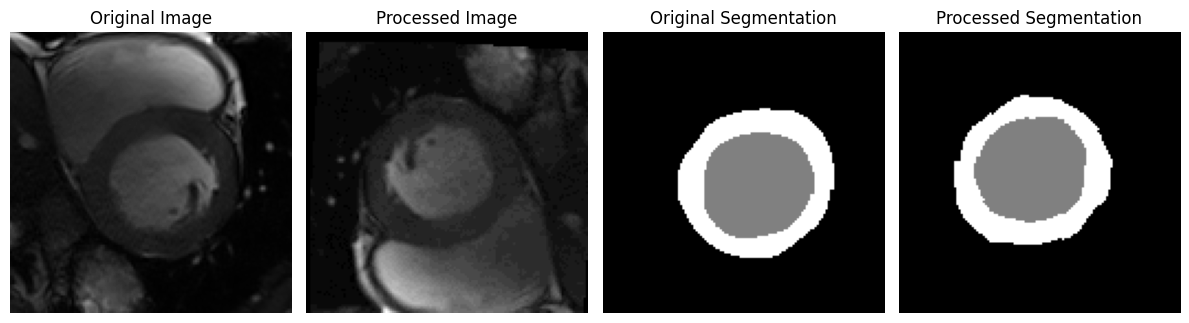

In [9]:
# let's try our dataload
# if you can error "local variable 'image_loaded' referenced before assignment", that's because you fail the code and directly run again. 
# to solve, please restart the jupyter notebook and run again
for batch_idx, batch_data in enumerate(dl):
    original_img = batch_data["original_image"]
    original_seg = batch_data["original_seg"]
    processed_img = batch_data["image"]
    processed_seg = batch_data["mask"]
    print('processed image shape:', processed_img.shape)
   
    # plot 4 images side by side --> you should see the data augmentation effects
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))
    axs[0].imshow(original_img[0,0,:,:], cmap='gray')
    axs[1].imshow(processed_img[0,0,:,:], cmap='gray')
    axs[2].imshow(original_seg[0,0,:,:], cmap='gray')
    axs[3].imshow(processed_seg[0,0,:,:], cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].set_title('Processed Image')
    axs[2].set_title('Original Segmentation')
    axs[3].set_title('Processed Segmentation')
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### step 4: load pre-trained SAM model (freeze SAM blocks)

In [10]:
# set model
model = build_model(args, device)

# set freezed and trainable keys
train_keys = []
freezed_keys = []
        
# load pretrained sam model vit_h
if args.model_type.startswith("sam"):
    if args.resume.endswith(".pth"):
        with open(args.resume, "rb") as f:
            state_dict = torch.load(f)
        try:
            model.load_state_dict(state_dict)
        except:
            if args.vit_type == "vit_h" or args.vit_type == "vit_l" or args.vit_type == "vit_b":
                new_state_dict = load_from(model, state_dict, args.img_size,  16, [7, 15, 23, 31])
               
            model.load_state_dict(new_state_dict)
        
        # freeze original SAM layers
        freeze_list = [ "norm1", "attn" , "mlp", "norm2"]  
                
        for n, value in model.named_parameters():
            if any(substring in n for substring in freeze_list):
                freezed_keys.append(n)
                value.requires_grad = False
            else:
                train_keys.append(n)
                value.requires_grad = True

## Select optimization method
optimizer = MADGRAD(model.parameters(), lr=args.lr) # momentum=,weight_decay=,eps=)
        
# Continue training model
if args.pretrained_model is not None:
    if os.path.exists(args.pretrained_model):
        print('loading pretrained model : ', args.pretrained_model)
        args.resume = args.pretrained_model
        finetune_checkpoint = torch.load(args.pretrained_model)
        model.load_state_dict(finetune_checkpoint["model"])
        optimizer.load_state_dict(finetune_checkpoint["optimizer"])
        torch.cuda.empty_cache()
else:
    print('new training\n')

Important! text prompt: False
Important! box prompt: False
new training

